In [ ]:
import pandas as pd
from rapidfuzz.distance import Levenshtein
from tqdm.notebook import tqdm
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import chess
from IPython.display import display, HTML
from statsmodels.stats.proportion import proportion_confint
from metrics.diversity_filtering import fen_to_padded


In [7]:
total = 0
for param in model.parameters():
    total += param.numel()
total

268892160

In [ ]:
base_path = Path("./Generate_positions/Lichess")
for path in os.listdir(base_path):
    if path[-4:] != ".csv":
        continue
    df = pd.read_csv(base_path / path)

    print(path[:-4])

    cols = [df["is_legal"], df["is_puzzle"], df[df["is_puzzle"]]["counter_intuitive"], df["is_puzzle"] & df["counter_intuitive"]]
    for col in cols:
        lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(df), alpha=0.05, method="normal")
        lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
        print(col.name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)


lichess_first_time_move_found_division_50
is_legal 100.0 [100.0, 100.0] 0.0
is_puzzle 83.57900000000001 [83.34938699788277, 83.80861300211724] 0.22961300211723312
counter_intuitive 1.5470393280608765 [1.2229801252194898, 1.3630198747805102] 0.0700198747805102
None 1.2930000000000001 [1.2229801252194898, 1.3630198747805102] 0.0700198747805102
lichess_first_time_move_found_division_50_small
is_legal 100.0 [100.0, 100.0] 0.0
is_puzzle 83.24000000000001 [82.50793248806879, 83.97206751193121] 0.7320675119312128
counter_intuitive 1.5617491590581452 [1.0779870316212894, 1.5220129683787105] 0.22201296837871054
None 1.3 [1.0779870316212894, 1.5220129683787105] 0.22201296837871054
lichess_first_time_settled_on_move_division_50_small
is_legal 100.0 [100.0, 100.0] 0.0
is_puzzle 83.26 [82.52828152408047, 83.99171847591953] 0.7317184759195285
counter_intuitive 3.687244775402354 [2.7318990546132804, 3.40810094538672] 0.33810094538671986
None 3.0700000000000003 [2.7318990546132804, 3.40810094538672] 0

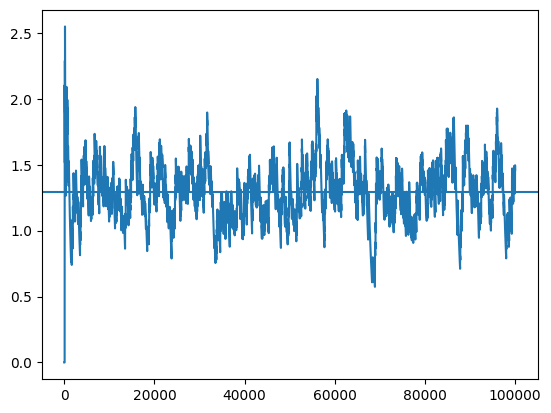

In [79]:
df = pd.read_csv(base_path / "lichess_first_time_move_found_division_50.csv")
(100 * (df["is_puzzle"] & df["counter_intuitive"])).ewm(alpha=1e-3).mean().plot()
plt.axhline((100 * (df["is_puzzle"] & df["counter_intuitive"])).mean(), 0, 100_000)
plt.show()

33


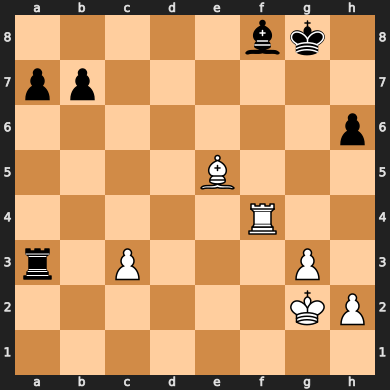

('5bk1/pp6/7p/4B3/5R2/r1P3P1/6KP/8 w - - 0 31',
 "('long', 'advantage', 'endgame', 'fork', 'exposedKing', 'sacrifice', 'attraction')",
 'f4f8 g8f8 e5d6 f8g7 d6a3',
 "['endgame', 'advantage', 'attraction', 'sacrifice', 'fork', 'exposedKing', 'long']")

In [29]:
base_path = Path("./Generate_positions/final_model/supervised/v4/test_context_no_move_last.csv")
df = pd.read_csv(base_path)
df = df[df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"]]
theme = "attraction"  # mateIn4
df = df[df["actual_themes"].apply(lambda x: theme in x)]
print(len(df))
row = df.sample(1).iloc[0]

display(chess.Board(row["fen"]))
row["fen"], row["target_themes"], row["main_line"], row["actual_themes"]

In [55]:
# base_path = Path("./Generate_positions/final_model/supervised/first_time_move_found_division_50/")
# base_path = Path("./Generate_positions/final_model/supervised/v4/")
base_path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/")
for path in os.listdir(base_path):
    if path[-4:] != ".csv":
        continue
    df = pd.read_csv(base_path / path)

    print(path[:-4])

    cols = [df["is_legal"], df["is_puzzle"], df[df["is_puzzle"]]["counter_intuitive"], df["is_puzzle"] & df["counter_intuitive"], df["themes_match"], df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"]]
    for col in cols:
        lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(df), alpha=0.05, method="normal")
        lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
        print(col.name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)


test_context_no_move_last
is_legal 99.8707 [99.86365685871499, 99.87774314128501] 0.007043141285009824
is_puzzle 25.2813 [25.1961151337756, 25.366484866224404] 0.08518486622440236
counter_intuitive 1.4473148137160667 [0.35406595280777603, 0.377734047192224] 0.011834047192223973
None 0.3659 [0.35406595280777603, 0.377734047192224] 0.011834047192223973
themes_match 78.71865766396506 [19.822847196073536, 19.97935280392646] 0.07825280392646228
None 0.2606 [0.250607626191293, 0.27059237380870693] 0.009992373808706961


In [26]:
index = -1
base_path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/")
# df = pd.read_csv("./Generate_positions/final_model/supervised/test_context_move_last.csv")
df = pd.read_csv(base_path / "test_context_no_move_last.csv")
temp = df[df["is_legal"] & df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"]]
temp = temp.sort_values("counter_intuitive_value", ascending=False)

In [84]:
temp.iloc[20]["target_themes"], temp.iloc[20]["actual_themes"]

("('advantage', 'endgame', 'short')",
 "['endgame', 'advantage', 'advancedPawn', 'quietMove', 'attackingF2F7', 'long']")

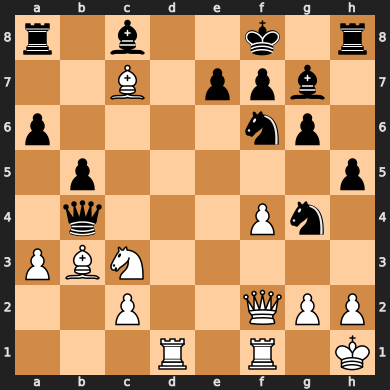

In [45]:
index = (index + 1) % len(temp)
row = temp.iloc[index]
board = chess.Board(row["fen"])
display(HTML(f"<h3>Puzzle {index + 1} / {len(temp)}</h3>"))
display(board)
display(HTML(f"<p style='font-size: 16px;'><b>Player to move:</b> {"white" if board.turn == chess.WHITE else "black"}</p>\n<p style='font-size: 16px;'><b>Solution:</b> {row['main_line']}</p>\n<p style='font-size: 16px;'><b>Themes:</b> {row['actual_themes']}</p>\n<p style='font-size: 16px;'><b>FEN:</b> {row['fen']}</p>\n<p style='font-size: 16px;'><b>cnt values:</b> {row['counter_intuitive_value']}</p><hr>"))


In [56]:
# dataset = pd.read_csv("./dataset/dataset.csv", nrows=1000000)
dataset = pd.read_csv("./dataset/dataset.csv")

In [58]:
dataset["Padded_FEN"] = [fen_to_padded(x) for x in dataset["Puzzle_FEN"]]

In [59]:
# def closest_matches(fen, dataset, n = 3):
#     board_fen = fen_to_padded(fen)
#     distances = dataset["Puzzle_FEN"].apply(lambda x: Levenshtein.distance(fen_to_padded(x), board_fen))
#     smallest = distances.nsmallest(n)
#     closest_indices = smallest.index
#     return dataset.loc[closest_indices][["Puzzle_FEN", "Themes", "Rating", "Moves"]], smallest.values

def closest_matches(fen, dataset, n=3):
    board_fen = fen_to_padded(fen)
    distances = np.array([
        Levenshtein.distance(x, board_fen) 
        for x in dataset["Padded_FEN"]
    ])
    
    if len(distances) > n:
        closest_indices = np.argpartition(distances, n)[:n]
        
        closest_indices = closest_indices[np.argsort(distances[closest_indices])]
    else:
        closest_indices = np.argsort(distances)
        
    smallest_values = distances[closest_indices]
    
    cols_to_return = ["Puzzle_FEN", "Themes", "Rating", "Moves"]
    return dataset.iloc[closest_indices][cols_to_return], smallest_values

In [52]:
def print_puzzles(puzzles):
    with pd.option_context("display.max_colwidth", 500):
        display(puzzles)

In [64]:
pos, dist = closest_matches("6k1/7p/pPp1P1pP/P4R2/6p1/r7/4r3/1K5R w - - 0 43", dataset)
print_puzzles(pos["Puzzle_FEN"])
print(dist)

3698499                 6k1/7p/p6P/P5K1/8/8/8/8 w - - 11 60
4215346          6k1/2R5/p2p1KP1/3P4/8/1p6/6r1/8 w - - 0 50
766327     6nk/3R4/2p1p1P1/p1r4P/8/P7/2P2r2/2K4R w - - 1 32
Name: Puzzle_FEN, dtype: object

[11 11 11]


In [65]:
pos, dist = closest_matches("r1b2k1r/2B1ppb1/p4np1/1p5p/1q3Pn1/PBN5/2P2QPP/3R1R1K w - - 1 22", dataset)
print_puzzles(pos["Puzzle_FEN"])
print(dist)

857240       r2r2k1/3N1pp1/p2bp2p/1p6/1q3P2/8/PP2Q1PP/3R1R1K w - - 4 23
3890981          r1b2r1k/1p4pp/2p5/p7/4P3/1Bb5/PPP3PP/3R1R1K w - - 0 19
5554174    5k1r/1b3pp1/pq4r1/1p5p/1P3Bn1/2N3Q1/1PP3P1/3R1R1K w - - 4 24
Name: Puzzle_FEN, dtype: object

[16 16 16]


In [66]:
pos, dist = closest_matches("2r1k3/4qpp1/1p2P2p/pP1Q1p2/2Np4/P1r2R2/2P3P1/7K w - - 1 34", dataset)
print_puzzles(pos["Puzzle_FEN"])
print(dist)

875150     4r1k1/5pp1/1p2P2p/p2Q1P2/2p5/2P1R1P1/2q2KP1/8 w - - 3 30
5182188              2r5/p4kpp/8/1p6/2Np4/1P5P/P1P3P1/7K w - - 0 25
2865965          4r1k1/6bp/p2p2q1/3P3p/4NP2/8/2Q3PP/4R2K w - - 3 32
Name: Puzzle_FEN, dtype: object

[14 14 14]
